In [4]:
import pandas as pd
import numpy as np

# Configuración de reproducibilidad
np.random.seed(42)

def generar_datos(n=100):
    # Definimos la población (100 estudiantes)
    grupos = ['Deportista', 'Sedentario']
    
    data = {
        'id_estudiante': range(1, n + 1),
        'habito_actividad': np.random.choice(grupos, size=n, p=[0.4, 0.6]),
        'puntuacion_estres': np.random.randint(1, 11, size=n)
    }
    
    df = pd.DataFrame(data)
    
    # Generamos las horas de sueño basadas en el grupo (Inferencia inicial)
    # Los deportistas duermen un poco más en nuestra simulación
    def simular_sueno(row):
        if row['habito_actividad'] == 'Deportista':
            return np.random.normal(7.5, 0.8)
        else:
            return np.random.normal(6.5, 1.2)
            
    df['horas_sueno'] = df.apply(simular_sueno, axis=1).round(1)
    
    return df

if __name__ == "__main__":
    df_estudiantes = generar_datos()
    print("--- Dataset Generado para la Lección 1 ---")
    print(df_estudiantes.head(10))
    
    # Guardamos el dataset inicial como pide el entregable
    df_estudiantes.to_csv('dataset_estudiantes.csv', index=False)
    print("\nArchivo 'dataset_estudiantes.csv' guardado con éxito.")

--- Dataset Generado para la Lección 1 ---
   id_estudiante habito_actividad  puntuacion_estres  horas_sueno
0              1       Deportista                  7          7.7
1              2       Sedentario                  1          4.8
2              3       Sedentario                  4          5.3
3              4       Sedentario                  4          7.4
4              5       Deportista                  5          6.1
5              6       Deportista                  7          7.6
6              7       Deportista                  7          8.3
7              8       Sedentario                  4          6.7
8              9       Sedentario                  7          5.8
9             10       Sedentario                  3          5.5

Archivo 'dataset_estudiantes.csv' guardado con éxito.


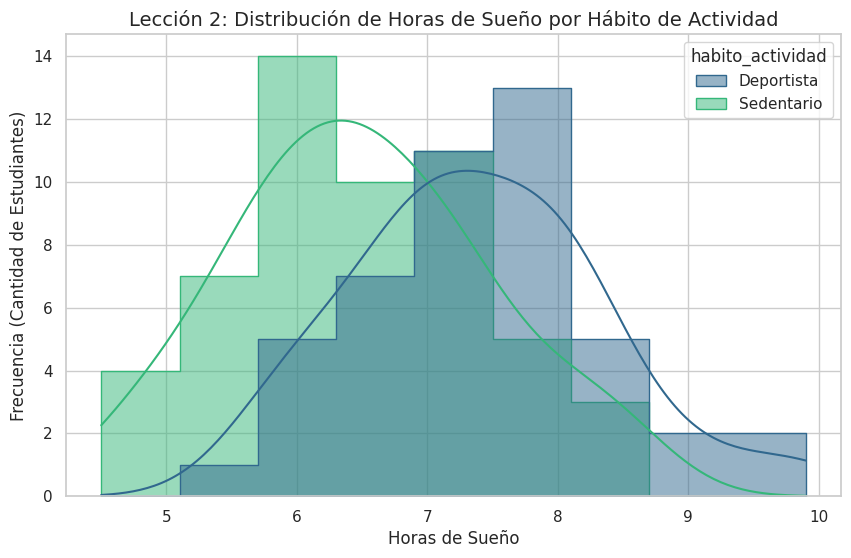

✅ Gráfico de la Lección 2 guardado como 'distribucion_sueno_L2.png'


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de estilo y lienzo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Histograma optimizado
# El parámetro 'hue' genera la leyenda automáticamente con los nombres de los grupos
sns.histplot(data=df_estudiantes, 
             x='horas_sueno', 
             hue='habito_actividad', 
             kde=True, 
             element="step", 
             palette="viridis", 
             alpha=0.5)

# 3. Personalización de títulos y ejes
plt.title('Lección 2: Distribución de Horas de Sueño por Hábito de Actividad', fontsize=14)
plt.xlabel('Horas de Sueño', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Estudiantes)', fontsize=12)

# Nota: No llamamos a plt.legend() manualmente para evitar el error, 
# ya que sns.histplot ya la incluye.

# 4. GUARDAR LA IMAGEN (Siempre antes de plt.show)
plt.savefig('distribucion_sueno_L2.png', dpi=300, bbox_inches='tight')

# 5. Mostrar resultado
plt.show()

print("✅ Gráfico de la Lección 2 guardado como 'distribucion_sueno_L2.png'")

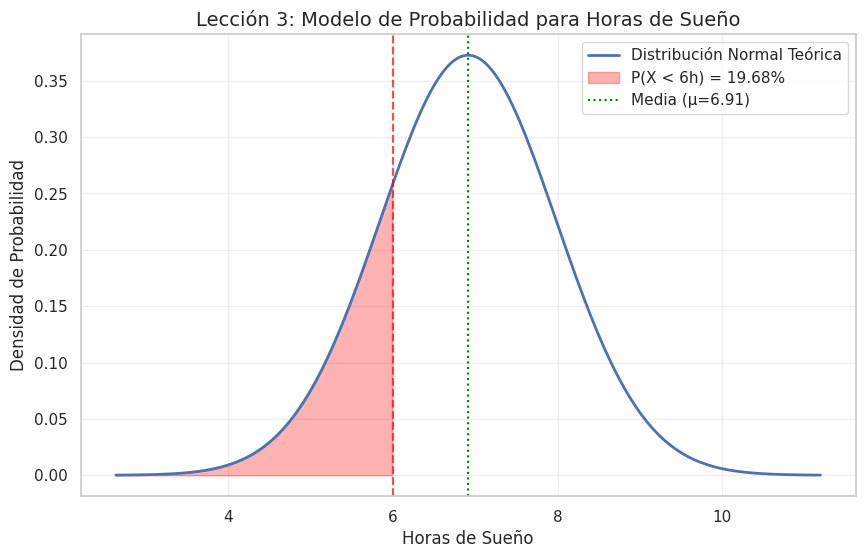

✅ Probabilidad calculada: 19.68%
✅ Gráfico de la Lección 3 guardado como 'modelo_probabilidad_L3.png'


In [6]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros de la distribución
mu = df_estudiantes['horas_sueno'].mean()
sigma = df_estudiantes['horas_sueno'].std()
limite_sueno = 6

# 2. Cálculo de probabilidad (CDF)
probabilidad_menos_6 = norm.cdf(limite_sueno, mu, sigma)

# 3. Configuración del gráfico
plt.figure(figsize=(10, 6))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y = norm.pdf(x, mu, sigma)

plt.plot(x, y, 'b', lw=2, label='Distribución Normal Teórica')
plt.fill_between(x, y, where=(x <= limite_sueno), color='red', alpha=0.3, 
                 label=f'P(X < 6h) = {probabilidad_menos_6:.2%}')

# Líneas de referencia
plt.axvline(limite_sueno, color='red', linestyle='--', alpha=0.7)
plt.axvline(mu, color='green', linestyle=':', label=f'Media (μ={mu:.2f})')

plt.title('Lección 3: Modelo de Probabilidad para Horas de Sueño', fontsize=14)
plt.xlabel('Horas de Sueño', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# 4. GUARDAR ANTES DE MOSTRAR
plt.savefig('modelo_probabilidad_L3.png', dpi=300, bbox_inches='tight')

# 5. Mostrar resultado
plt.show()

print(f"✅ Probabilidad calculada: {probabilidad_menos_6:.2%}")
print("✅ Gráfico de la Lección 3 guardado como 'modelo_probabilidad_L3.png'")

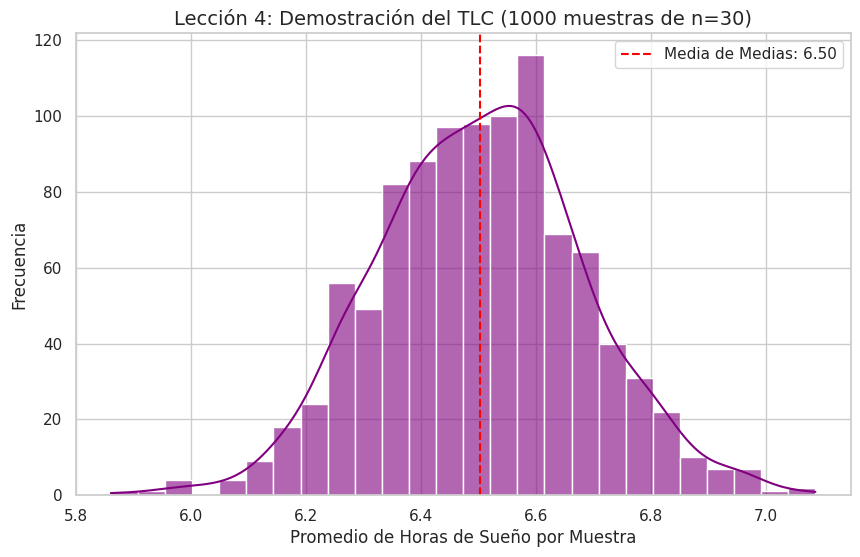

--- Resultados de la Simulación ---
Media de la población original: 6.50
Media de la distribución de promedios: 6.50
✅ Gráfico de la Lección 4 guardado como 'teorema_limite_central_L4.png'


In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos
datos_sedentarios = df_estudiantes[df_estudiantes['habito_actividad'] == 'Sedentario']['horas_sueno']

# 2. Simulación optimizada (TLC)
n_muestras = 1000
tamano_muestra = 30
# Usamos una lista de comprensión para que sea más rápido
promedios_muestrales = [np.random.choice(datos_sedentarios, size=tamano_muestra, replace=True).mean() 
                        for _ in range(n_muestras)]

# 3. Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.histplot(promedios_muestrales, kde=True, color='purple', alpha=0.6)

# Marcamos la media de medias
media_de_medias = np.mean(promedios_muestrales)
plt.axvline(media_de_medias, color='red', linestyle='--', 
            label=f'Media de Medias: {media_de_medias:.2f}')

plt.title(f'Lección 4: Demostración del TLC ({n_muestras} muestras de n={tamano_muestra})', fontsize=14)
plt.xlabel('Promedio de Horas de Sueño por Muestra', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

# 4. GUARDAR ANTES DE MOSTRAR
plt.savefig('teorema_limite_central_L4.png', dpi=300, bbox_inches='tight')

# 5. Mostrar resultado
plt.show()

# Resumen numérico para el informe
print(f"--- Resultados de la Simulación ---")
print(f"Media de la población original: {datos_sedentarios.mean():.2f}")
print(f"Media de la distribución de promedios: {media_de_medias:.2f}")
print("✅ Gráfico de la Lección 4 guardado como 'teorema_limite_central_L4.png'")

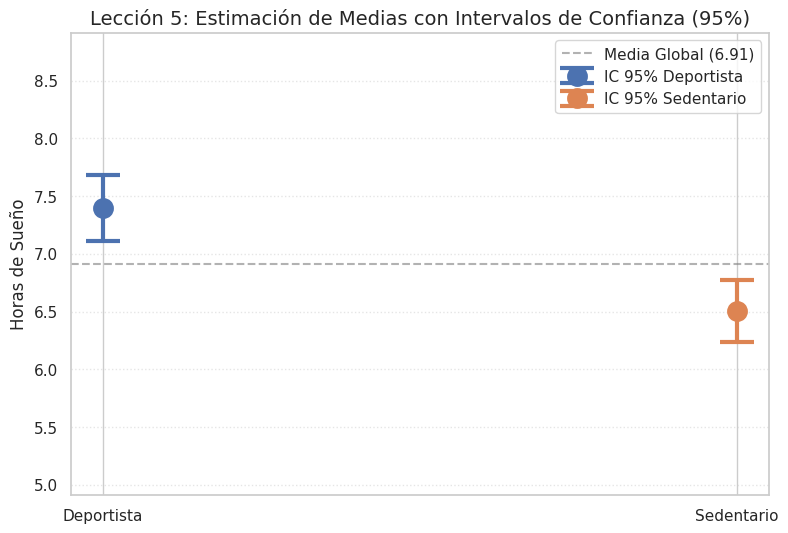

--- REPORTE DE LA LECCIÓN 5 ---
Grupo Deportista: 7.40 hrs | IC: [7.11 - 7.68]
Grupo Sedentario: 6.50 hrs | IC: [6.23 - 6.77]

✅ Gráfico de la Lección 5 guardado como 'intervalos_confianza_L5.png'


In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

def calcular_intervalo_confianza(data, confianza=0.95):
    n = len(data)
    media = np.mean(data)
    std_err = stats.sem(data) # Error estándar de la media
    # Usamos t.interval para mayor precisión con muestras pequeñas (n < 30) o grandes
    intervalo = stats.t.interval(confianza, n-1, loc=media, scale=std_err)
    return intervalo

# 1. Cálculo de Intervalos por Grupo
grupos = df_estudiantes['habito_actividad'].unique()
resultados_ic = {}

for g in grupos:
    datos_g = df_estudiantes[df_estudiantes['habito_actividad'] == g]['horas_sueno']
    ic = calcular_intervalo_confianza(datos_g)
    resultados_ic[g] = {'media': datos_g.mean(), 'ic_inf': ic[0], 'ic_sup': ic[1]}

# 2. Configuración del Gráfico de Inferencia
plt.figure(figsize=(9, 6))

for g, v in resultados_ic.items():
    # Calculamos el tamaño del error (distancia de la media al límite)
    error_y = [[v['media'] - v['ic_inf']], [v['ic_sup'] - v['media']]]
    
    plt.errorbar(g, v['media'], yerr=error_y, 
                 fmt='o', capsize=12, markersize=12, elinewidth=3, markeredgewidth=3,
                 label=f'IC 95% {g}')

# Línea de referencia global
media_global = df_estudiantes['horas_sueno'].mean()
plt.axhline(media_global, color='gray', linestyle='--', alpha=0.6, label=f'Media Global ({media_global:.2f})')

plt.title('Lección 5: Estimación de Medias con Intervalos de Confianza (95%)', fontsize=14)
plt.ylabel('Horas de Sueño', fontsize=12)
plt.ylim(media_global - 2, media_global + 2) # Ajuste de escala para mejor visibilidad
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 3. GUARDAR ANTES DE MOSTRAR (Regla de oro)
plt.savefig('intervalos_confianza_L5.png', dpi=300, bbox_inches='tight')

# 4. Mostrar y Reportar
plt.show()

print("--- REPORTE DE LA LECCIÓN 5 ---")
for g, v in resultados_ic.items():
    print(f"Grupo {g}: {v['media']:.2f} hrs | IC: [{v['ic_inf']:.2f} - {v['ic_sup']:.2f}]")
print("\n✅ Gráfico de la Lección 5 guardado como 'intervalos_confianza_L5.png'")

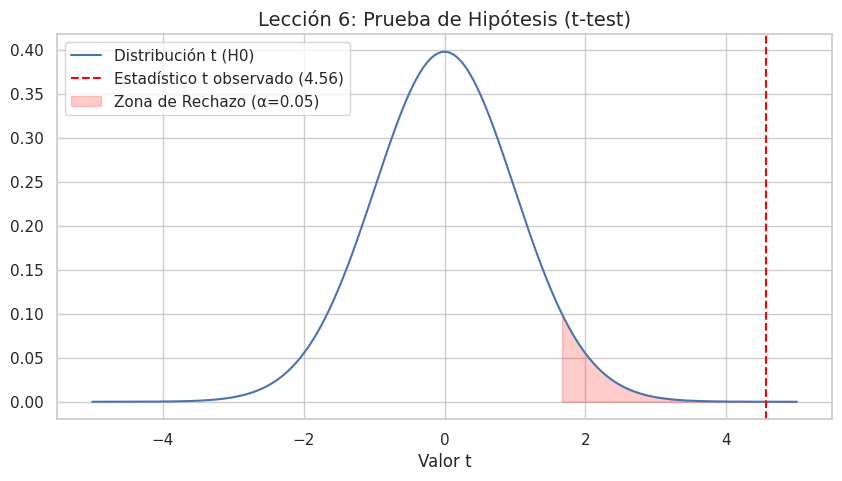

--- CONCLUSIÓN ESTADÍSTICA FINAL ---
Estadístico t: 4.5645
Valor p: 0.0000148390

✅ RESULTADO: Se RECHAZA H0 (p < 0.05)
Conclusión: La diferencia es estadísticamente significativa. El ejercicio físico impacta positivamente en el sueño.

📸 Gráfico final guardado como 'prueba_hipotesis_L6.png'


In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparación de muestras
deportistas = df_estudiantes[df_estudiantes['habito_actividad'] == 'Deportista']['horas_sueno']
sedentarios = df_estudiantes[df_estudiantes['habito_actividad'] == 'Sedentario']['horas_sueno']

# 2. Ejecución del Test de Welch (Varianzas no necesariamente iguales)
t_stat, p_val = stats.ttest_ind(deportistas, sedentarios, equal_var=False)

# 3. Visualización de la Prueba de Hipótesis
plt.figure(figsize=(10, 5))
# Generamos una distribución t para el gráfico
x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, df=len(deportistas)+len(sedentarios)-2)

plt.plot(x, y, label='Distribución t (H0)')
plt.axvline(t_stat, color='red', linestyle='--', label=f'Estadístico t observado ({t_stat:.2f})')

# Colorear zona de rechazo (Alpha = 0.05)
critical_t = stats.t.ppf(1 - 0.05, df=len(deportistas)+len(sedentarios)-2)
plt.fill_between(x, y, where=(x >= critical_t), color='red', alpha=0.2, label='Zona de Rechazo (α=0.05)')

plt.title('Lección 6: Prueba de Hipótesis (t-test)', fontsize=14)
plt.xlabel('Valor t', fontsize=12)
plt.legend()

# 4. GUARDAR ANTES DE MOSTRAR
plt.savefig('prueba_hipotesis_L6.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Reporte Final Automático
print("--- CONCLUSIÓN ESTADÍSTICA FINAL ---")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val:.10f}")

alpha = 0.05
if p_val < alpha:
    print(f"\n✅ RESULTADO: Se RECHAZA H0 (p < {alpha})")
    print("Conclusión: La diferencia es estadísticamente significativa. El ejercicio físico impacta positivamente en el sueño.")
else:
    print(f"\n❌ RESULTADO: NO se rechaza H0 (p >= {alpha})")
    print("Conclusión: No hay evidencia suficiente para afirmar una diferencia.")

print("\n📸 Gráfico final guardado como 'prueba_hipotesis_L6.png'")